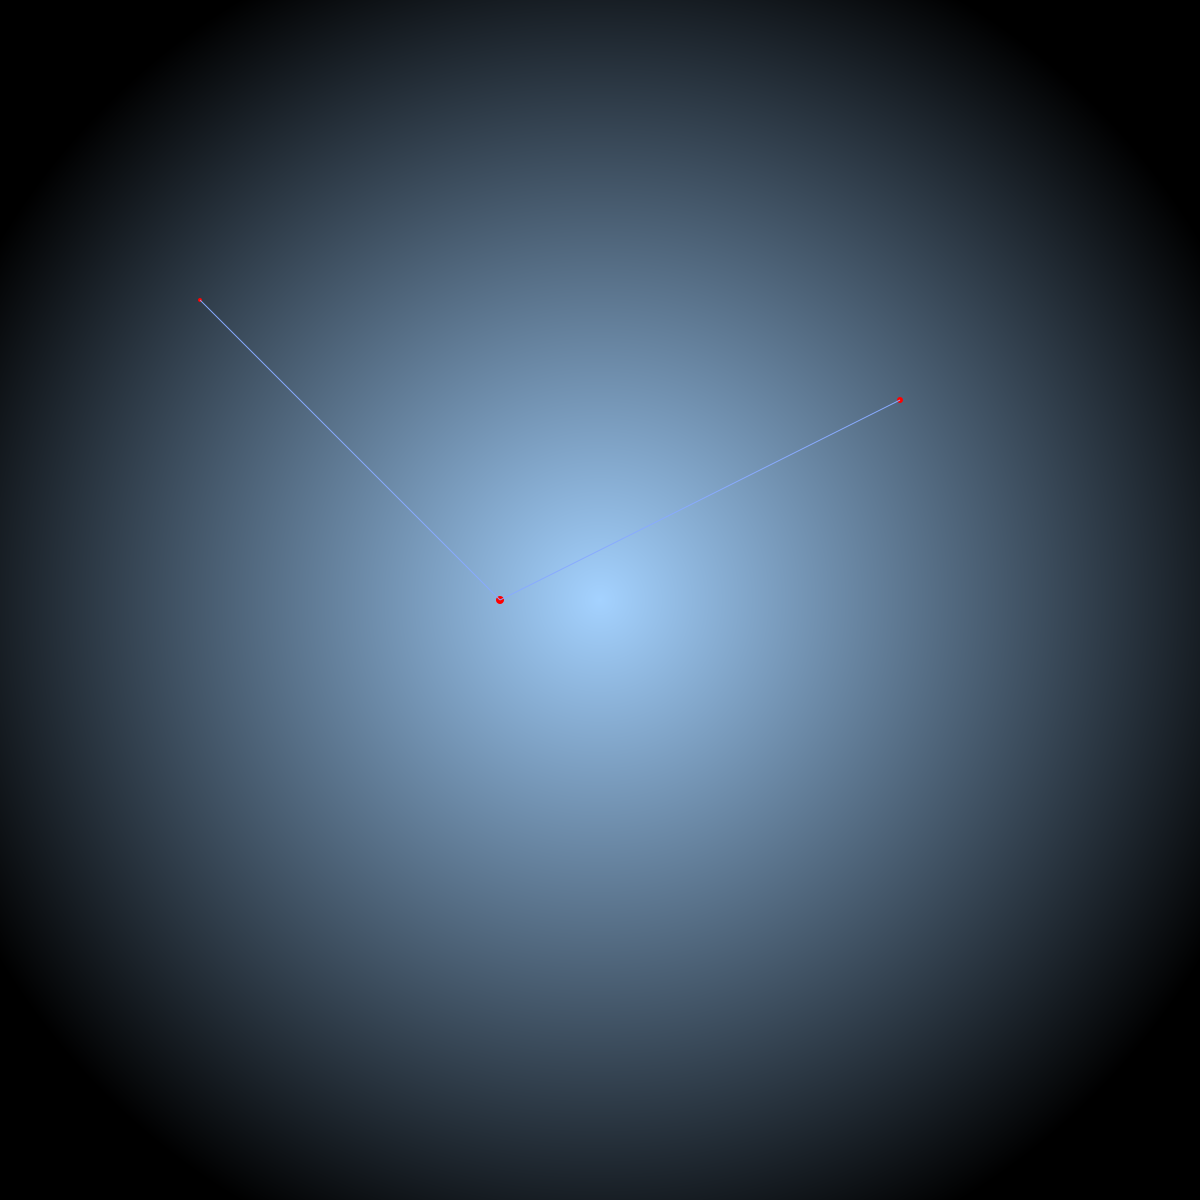

In [1]:
import drawsvg as draw

d = draw.Drawing(1200, 1200)

# Background gradient
grad = draw.RadialGradient(600, 600, 700)
grad.add_stop(0, "#A4D2FF")
grad.add_stop(1, '#000000')

d.append(draw.Rectangle(
    0, 0, 1200, 1200,
    fill=grad
))

# Star positions
stars = [
    (200, 300, 2),
    (500, 600, 4),
    (900, 400, 3),
]

# Draw stars
for x, y, r in stars:
    d.append(draw.Circle(
        x, y, r,
        fill='red'
    ))

# Constellation lines
lines = [
    ((200, 300), (500, 600)),
    ((500, 600), (900, 400)),
]

for (x1, y1), (x2, y2) in lines:
    d.append(draw.Line(
        x1, y1,
        x2, y2,
        stroke='#88aaff',
        stroke_width=1
    ))

d.save_svg('chart.svg')
d

In [7]:
import drawsvg as draw
from xml.etree import ElementTree as ET

SVG_NS = '{http://www.w3.org/2000/svg}'


def load_svg_marker(svg_file):
    """
    Load an SVG file and convert all paths into a reusable drawsvg Group.
    Supports multiple paths/groups.
    """

    tree = ET.parse(svg_file)
    root = tree.getroot()

    group = draw.Group()

    # Read viewBox
    viewbox = root.attrib.get('viewBox', '0 0 100 100')
    _, _, width, height = map(float, viewbox.split())

    # Find ALL paths
    for path in root.findall(f'.//{SVG_NS}path'):

        d = path.attrib.get('d')
        style = path.attrib.get('style', '')

        # Extract fill from style if present
        fill = 'white'

        for item in style.split(';'):
            if item.startswith('fill:'):
                fill = item.split(':')[1]

        group.append(
            draw.Path(
                d=d,
                fill=fill
            )
        )

    return group, width, height

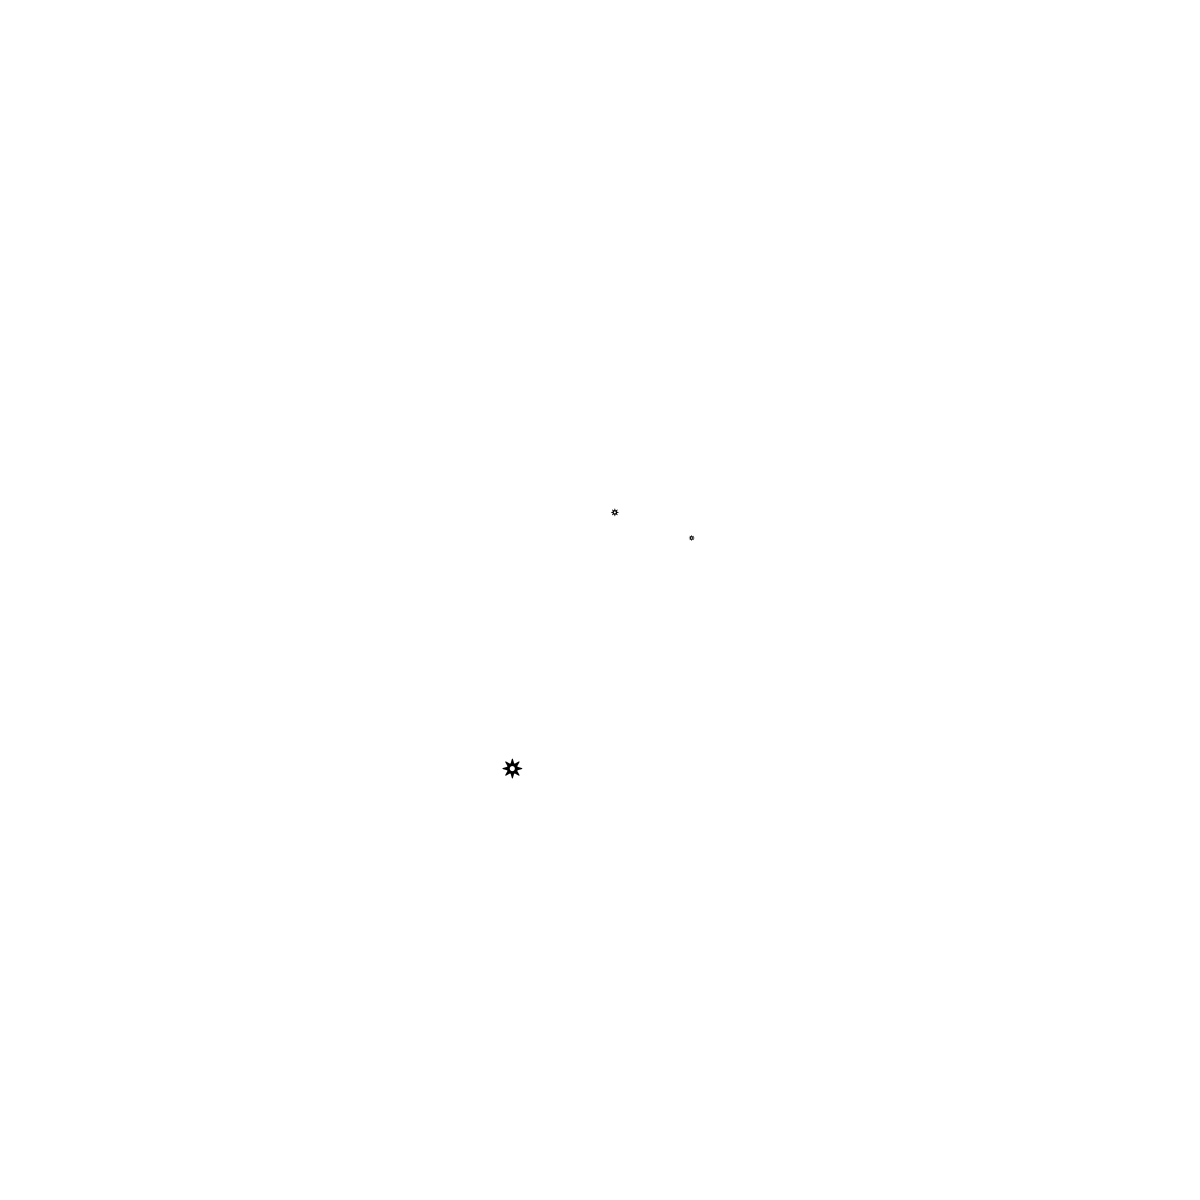

In [ ]:
import drawsvg as draw

# ---------------------------------------
# Load marker
# ---------------------------------------

marker, w, h = load_svg_marker('star_marker_0.svg')

# ---------------------------------------
# Create drawing
# ---------------------------------------

d = draw.Drawing(1200, 1200)

d.append(
    draw.Rectangle(
        0, 0, 1200, 1200,
        fill='white'
    )
)

# ---------------------------------------
# Star positions
# ---------------------------------------

stars = [
    (200, 300, 20),
    (600, 500, 8),
    (900, 700, 6),
]

# ---------------------------------------
# Plot markers
# ---------------------------------------

for x, y, size in stars:

    scale = size / max(w, h)

    d.append(
        draw.Use(
            marker,
            x=x, y=y,, fill='red'
        )
    )

# ---------------------------------------
# Save
# ---------------------------------------

d.save_svg('chart.svg')
d